In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

In [2]:
def plot_stage2_fir_tf(num_taps=63, cutoff_ratio=0.8, R2=16, fs_in=781250.0):
    fs_out = fs_in / R2
    nyq_out = fs_out / 2.0
    cutoff_freq = cutoff_ratio * nyq_out
    
    # 1. Design FIR Taps
    taps = signal.firwin(num_taps, cutoff_freq, fs=fs_in, window=('kaiser', 5.0))
    
    # 2. Manual TF Calculation (No freqz needed)
    f = np.linspace(0, fs_in / 2, 5000)
    omega = 2 * np.pi * f / fs_in
    n = np.arange(len(taps))
    
    # H(e^jw) = sum( h[n] * exp(-j * n * w) )
    H_complex = np.dot(np.exp(-1j * np.outer(omega, n)), taps)
    magnitude_db = 20 * np.log10(np.abs(H_complex) + 1e-12)
    
    # 3. Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(f, magnitude_db, label=f'Stage 2 FIR TF (Taps={num_taps}, R2={R2})', color='blue', linewidth=2)
    plt.axvline(nyq_out, color='red', linestyle='--', alpha=0.7, label=f'Output Nyquist Bound ({nyq_out:.1f} Hz)')
    
    for i in range(1, int(R2/2) + 1):
        null_freq = i * fs_out
        if null_freq < fs_in / 2:
            plt.axvline(null_freq, color='green', linestyle=':', alpha=0.5)
            plt.axvspan(null_freq - nyq_out, min(null_freq + nyq_out, fs_in / 2), 
                        color='gray', alpha=0.1, label='Aliasing Zone' if i == 1 else "")

    plt.title(f'Stage 2 FIR Frequency Response via Transfer Function\n(Input Rate: {fs_in:.2f} Hz $\\rightarrow$ Output Rate: {fs_out:.2f} Hz)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.ylim([-100, 5])
    plt.grid(True, which='both', linestyle='-', alpha=0.4)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


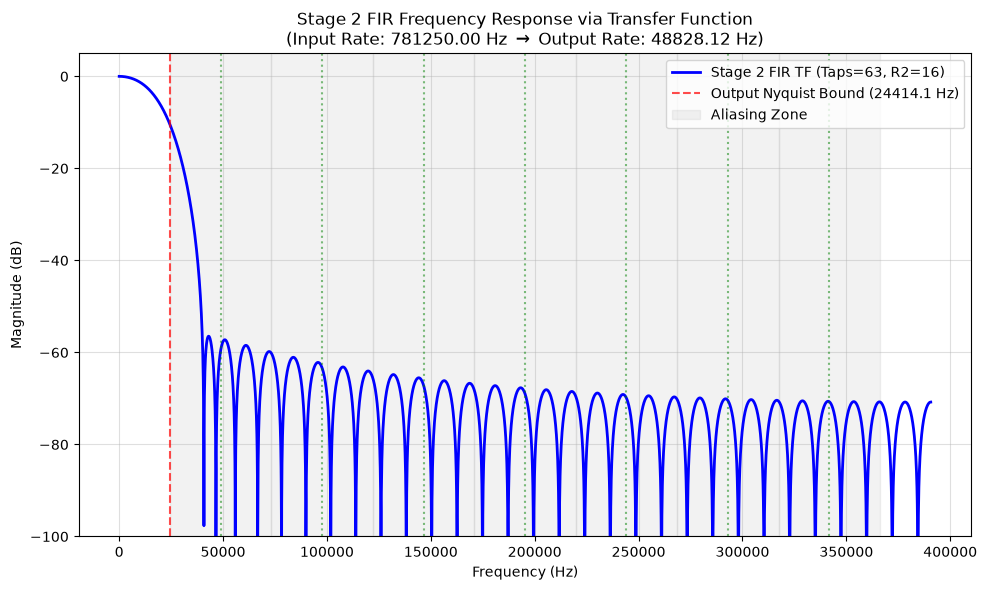

In [3]:
plot_stage2_fir_tf(
    num_taps=63,
    cutoff_ratio=0.8,
    R2= 16,
    fs_in=781250
)

In [4]:
def plot_stage2_fir_with_decimation(num_taps=63, cutoff_ratio=0.8, R2=16, fs_in=781250.0):
    fs_out = fs_in / R2
    nyq_out = fs_out / 2.0
    cutoff_freq = cutoff_ratio * nyq_out
    
    # 1. Design FIR Taps
    taps = signal.firwin(num_taps, cutoff_freq, fs=fs_in, window=('kaiser', 5.0))
    
    # 2. Pre-Decimation Frequency Domain Evaluation (0 to fs_in / 2)
    f_in_grid = np.linspace(0, fs_in / 2, 10000)
    omega_in = 2 * np.pi * f_in_grid / fs_in
    n = np.arange(len(taps))
    
    # Transfer Function: H(e^jw) = sum( h[n] * exp(-j * n * w) )
    H_in = np.dot(np.exp(-1j * np.outer(omega_in, n)), taps)
    mag_in_db = 20 * np.log10(np.abs(H_in) + 1e-12)
    
    # 3. Post-Decimation Folded Spectrum Evaluation (0 to fs_out / 2)
    f_out_grid = np.linspace(1e-5, nyq_out, 2000)
    H_folded = np.zeros(len(f_out_grid), dtype=complex)
    
    # Sum up all R2 aliasing spectral folds
    for k in range(R2):
        # Shifted frequencies in input domain
        f_shifted = f_out_grid + (k * fs_out)
        omega_shifted = 2 * np.pi * f_shifted / fs_in
        
        # Evaluate H(e^jw) at shifted frequency and accumulate
        H_k = np.dot(np.exp(-1j * np.outer(omega_shifted, n)), taps)
        H_folded += H_k
        
    H_folded = H_folded / R2  # Scale by decimation factor
    mag_folded_db = 20 * np.log10(np.abs(H_folded) + 1e-12)

    # 4. Plotting Both Perspectives
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Plot 1: Pre-Decimation Response on Input Frequency Grid
    ax1.plot(f_in_grid, mag_in_db, label=f'Stage 2 FIR TF (Taps={num_taps})', color='blue')
    ax1.axvline(nyq_out, color='red', linestyle='--', label=f'Output Nyquist ({nyq_out:.1f} Hz)')
    
    for i in range(1, int(R2/2) + 1):
        null_freq = i * fs_out
        if null_freq < fs_in / 2:
            ax1.axvline(null_freq, color='green', linestyle=':', alpha=0.5)
            ax1.axvspan(null_freq - nyq_out, min(null_freq + nyq_out, fs_in / 2), 
                        color='gray', alpha=0.1)

    ax1.set_title(f'1. Pre-Decimation Frequency Response (Input Sampling Rate: {fs_in:.2f} Hz)')
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel('Magnitude (dB)')
    ax1.set_ylim([-100, 5])
    ax1.grid(True, alpha=0.4)
    ax1.legend(loc='upper right')

    # Plot 2: Post-Decimation Folded Spectrum on Output Baseband Grid
    ax2.plot(f_out_grid, mag_folded_db, color='purple', linewidth=2, 
             label=f'Decimated Baseband Spectrum (fs_out = {fs_out:.2f} Hz)')
    ax2.set_title('2. Post-Decimation Baseband Spectrum (Includes Alias Folding Effects)')
    ax2.set_xlabel('Baseband Frequency (Hz)')
    ax2.set_ylabel('Magnitude (dB)')
    ax2.set_ylim([-100, 5])
    ax2.set_xlim([0, nyq_out])
    ax2.grid(True, alpha=0.4)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

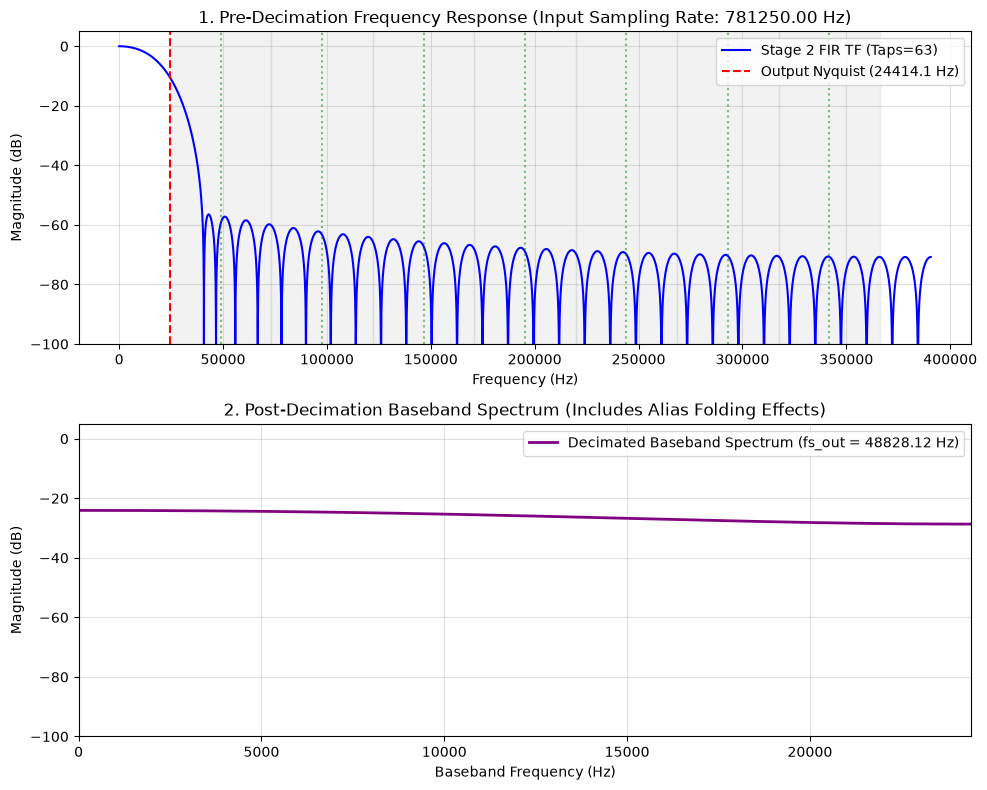

In [5]:
plot_stage2_fir_with_decimation(num_taps=63, cutoff_ratio=0.8, R2=16, fs_in=781250.0)

In [6]:
def design_halfband_fir(num_taps=31):
    """
    Designs a Type-1 Linear Phase Half-Band FIR filter.
    Ensures num_taps is odd (4k+3 or 4k+1) so every even-indexed tap 
    (except center) is forced to EXACTLY 0.
    """
    if num_taps % 2 == 0:
        num_taps += 1  # Half-band filters must have odd length
        
    # Cutoff at fs/4 (0.25 normalized)
    taps = signal.firwin(num_taps, 0.25, window=('kaiser', 5.0), fs=1.0)
    
    # Enforce strict zero-taps for half-band symmetry
    center = num_taps // 2
    for i in range(num_taps):
        if (i - center) % 2 == 0 and i != center:
            taps[i] = 0.0
            
    # Force center tap to exactly 0.5 for ideal 6 dB passband gain
    taps[center] = 0.5
    return taps

In [11]:
def plot_stage2_halfband_cascade(hb_taps_count=31, fs_in=781250.0, f_max_plot=400000.0):
    """
    Plots the frequency response for STAGE 2 ONLY.
    Cascades 4 Half-Band FIR stages (R2 = 2^4 = 16).
    
    Parameters:
    -----------
    hb_taps_count : int - Number of taps for each Half-Band stage
    fs_in : float - Input sampling rate to Stage 2 (Output of Stage 1, default = 781.25 kHz)
    f_max_plot : float - Maximum frequency limit for the x-axis plot in Hz
    """
    # 1. Calculate Sampling Rates through Stage 2 (4 stages of R=2)
    fs_hb1 = fs_in               # Stage 2 Input: 781.25 kHz
    fs_hb2 = fs_hb1 / 2.0        # After HB1: 390.625 kHz
    fs_hb3 = fs_hb2 / 2.0        # After HB2: 195.3125 kHz
    fs_hb4 = fs_hb3 / 2.0        # After HB3: 97.65625 kHz
    fs_out  = fs_hb4 / 2.0        # Stage 2 Final Output: 48.828125 kHz
    
    nyq_out = fs_out / 2.0       # Final Stage 2 Nyquist Bound (24.414 kHz)
    
    # 2. Design base Half-Band Taps
    hb_taps = design_halfband_fir(hb_taps_count)
    n_hb = np.arange(len(hb_taps))
    
    # 3. Frequency evaluation grid across Stage 2 input Nyquist
    f_grid = np.linspace(1e-5, f_max_plot, 8000)
    
    # Individual frequency responses for each of the 4 Half-Band stages
    # HB1 operating at fs_hb1
    omega_hb1 = 2 * np.pi * f_grid / fs_hb1
    H_hb1 = np.dot(np.exp(-1j * np.outer(omega_hb1, n_hb)), hb_taps)
    
    # HB2 operating at fs_hb2
    omega_hb2 = 2 * np.pi * f_grid / fs_hb2
    H_hb2 = np.dot(np.exp(-1j * np.outer(omega_hb2, n_hb)), hb_taps)
    
    # HB3 operating at fs_hb3
    omega_hb3 = 2 * np.pi * f_grid / fs_hb3
    H_hb3 = np.dot(np.exp(-1j * np.outer(omega_hb3, n_hb)), hb_taps)
    
    # HB4 operating at fs_hb4
    omega_hb4 = 2 * np.pi * f_grid / fs_hb4
    H_hb4 = np.dot(np.exp(-1j * np.outer(omega_hb4, n_hb)), hb_taps)

    # 4. Total Stage 2 Cascaded Response
    H_stage2_total = H_hb1 * H_hb2 * H_hb3 * H_hb4
    mag_stage2_db = 20 * np.log10(np.abs(H_stage2_total) + 1e-12)

    # 5. Plotting
    plt.figure(figsize=(11, 6))
    
    # Plot Stage 2 Combined Cascade
    plt.plot(f_grid, mag_stage2_db, color='blue', linewidth=2, 
             label=f'Stage 2 Composite (4x HB FIR, Taps={len(hb_taps)}, R2=16)')
    
    # Mark Final Stage 2 Nyquist Boundary
    plt.axvline(nyq_out, color='red', linestyle='--', linewidth=1.5, 
                label=f'Stage 2 Nyquist Bound ({nyq_out/1e3:.2f} kHz)')

    # Add Green Dotted Markers for multiples of Stage 2 Output Rate (Alias Centers)
    max_k = int(f_max_plot / fs_out) + 1
    first_green = True
    for i in range(1, max_k):
        null_freq = i * fs_out
        if null_freq <= f_max_plot:
            plt.axvline(null_freq, color='green', linestyle=':', alpha=0.5, 
                        label='Alias Center Markers' if first_green else "")
            
            # Shade Aliasing Bands
            alias_start = max(0, null_freq - nyq_out)
            alias_end = min(f_max_plot, null_freq + nyq_out)
            plt.axvspan(alias_start, alias_end, color='gray', alpha=0.08)
            first_green = False

    plt.title(f'Stage 2 Frequency Response: 4x Cascaded Half-Band FIR Filters\n(Input Rate: {fs_in/1e3:.2f} kHz $\\rightarrow$ Output Rate: {fs_out/1e3:.2f} kHz | R2 = 16)')
    plt.xlabel('Frequency (Hz)', fontsize=11)
    plt.ylabel('Magnitude (dB)', fontsize=11)
    plt.ylim([-120, 5])
    plt.xlim([0, f_max_plot])
    plt.grid(True, linestyle='-', alpha=0.4)
    plt.legend(loc='upper right', framealpha=0.9)
    plt.tight_layout()
    plt.show()

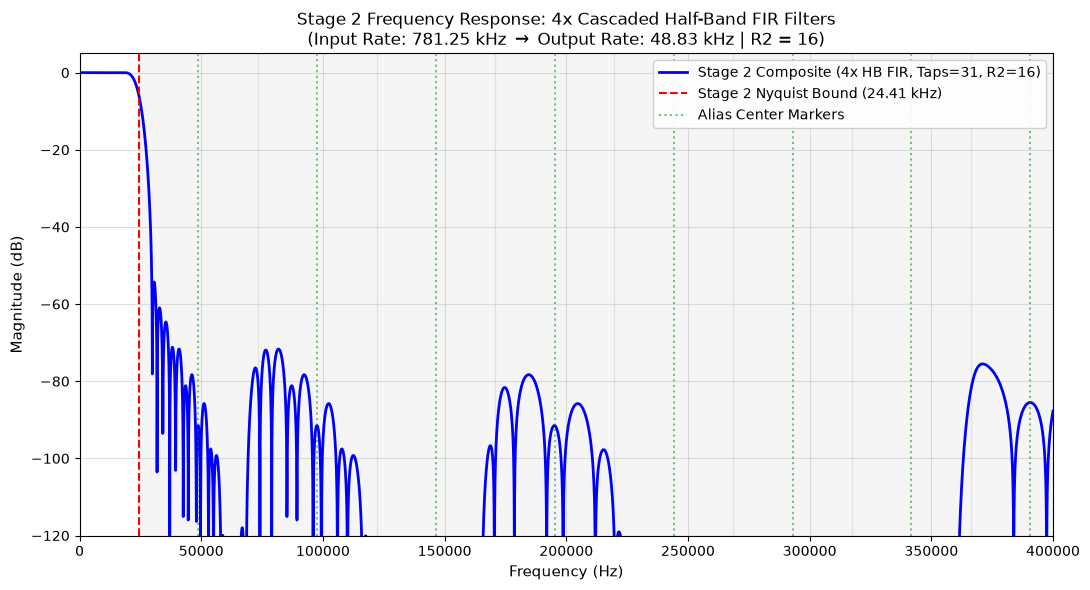

In [12]:
plot_stage2_halfband_cascade(hb_taps_count=31, fs_in=781250.0, f_max_plot=400000.0)

In [9]:
def plot_cic_with_4_halfband_cascade(
    R1=16, M=1, N_cic=4,      # Stage 1 CIC
    hb_taps_count=31,         # Taps per Half-Band stage
    fs_in=12500000.0,         # High input rate (12.5 MHz)
    f_max_plot=1e6            # View limit (1 MHz)
):
    """
    Cascades Stage 1 CIC (R1=16) with 4 Half-Band FIR Stages (R2_total = 2^4 = 16)
    Total Decimation R_total = 16 * 16 = 256
    """
    # -------------------------------------------------------------------------
    # 1. Setup Sampling Rates across the 5 total stages
    # -------------------------------------------------------------------------
    fs_stage1_out = fs_in / R1                    # 781.25 kHz
    fs_hb1_out = fs_stage1_out / 2                 # 390.625 kHz
    fs_hb2_out = fs_hb1_out / 2                    # 195.3125 kHz
    fs_hb3_out = fs_hb2_out / 2                    # 97.65625 kHz
    fs_hb4_out = fs_hb3_out / 2                    # 48.828125 kHz (Final Rate)
    
    nyq_final = fs_hb4_out / 2.0                   # 24.414 kHz
    
    # Design base Half-Band Taps
    hb_taps = design_halfband_fir(hb_taps_count)
    n_hb = np.arange(len(hb_taps))
    
    # -------------------------------------------------------------------------
    # 2. Evaluate Frequency Grid (0 to fs_in / 2)
    # -------------------------------------------------------------------------
    f_grid = np.linspace(1e-5, f_max_plot, 8000)
    
    # A. Stage 1: CIC Response
    omega_in = 2 * np.pi * f_grid / fs_in
    dc_gain_cic = (R1 * M) ** N_cic
    num_cic = 1 - np.exp(-1j * omega_in * R1 * M)
    den_cic = 1 - np.exp(-1j * omega_in)
    H_cic = np.where(np.abs(den_cic) < 1e-12, dc_gain_cic, num_cic / den_cic) ** N_cic
    H_cic_norm = H_cic / dc_gain_cic

    # B. Stage 2: 4 Half-Band FIR Stages in Series
    # HB1 runs at fs_stage1_out
    omega_hb1 = 2 * np.pi * f_grid / fs_stage1_out
    H_hb1 = np.dot(np.exp(-1j * np.outer(omega_hb1, n_hb)), hb_taps)
    
    # HB2 runs at fs_hb1_out
    omega_hb2 = 2 * np.pi * f_grid / fs_hb1_out
    H_hb2 = np.dot(np.exp(-1j * np.outer(omega_hb2, n_hb)), hb_taps)
    
    # HB3 runs at fs_hb2_out
    omega_hb3 = 2 * np.pi * f_grid / fs_hb2_out
    H_hb3 = np.dot(np.exp(-1j * np.outer(omega_hb3, n_hb)), hb_taps)
    
    # HB4 runs at fs_hb3_out
    omega_hb4 = 2 * np.pi * f_grid / fs_hb3_out
    H_hb4 = np.dot(np.exp(-1j * np.outer(omega_hb4, n_hb)), hb_taps)

    # C. Cascaded Combined Transfer Function
    H_hb_cascade = H_hb1 * H_hb2 * H_hb3 * H_hb4
    H_total = H_cic_norm * H_hb_cascade
    
    # Magnitude conversions
    mag_cic_db = 20 * np.log10(np.abs(H_cic_norm) + 1e-12)
    mag_hb_db = 20 * np.log10(np.abs(H_hb_cascade) + 1e-12)
    mag_total_db = 20 * np.log10(np.abs(H_total) + 1e-12)

    # -------------------------------------------------------------------------
    # 3. Plotting
    # -------------------------------------------------------------------------
    plt.figure(figsize=(11, 6))
    
    plt.plot(f_grid, mag_cic_db, '--', color='gray', alpha=0.5, label='Stage 1: CIC Only')
    plt.plot(f_grid, mag_hb_db, ':', color='orange', linewidth=1.5, label='Stage 2: 4x Half-Band Cascade Only')
    plt.plot(f_grid, mag_total_db, color='blue', linewidth=2, label='Total Composite (CIC + 4x HB FIR)')
    
    plt.axvline(nyq_final, color='red', linestyle='--', label=f'Final Nyquist Limit ({nyq_final/1e3:.2f} kHz)')

    # Add harmonic marker lines for the final output sampling rate
    max_k = int(f_max_plot / fs_hb4_out) + 1
    first_green = True
    for i in range(1, max_k):
        null_freq = i * fs_hb4_out
        if null_freq <= f_max_plot:
            plt.axvline(null_freq, color='green', linestyle=':', alpha=0.3, 
                        label='Alias Center Markers' if first_green else "")
            first_green = False

    plt.title(f'Multi-Stage Decimation: CIC (R1=16) + 4x Half-Band FIR (2^4=16)\nTotal Decimation R = 256 | Input: {fs_in/1e6:.1f} MHz -> Output: {fs_hb4_out/1e3:.2f} kHz')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.ylim([-120, 5])
    plt.xlim([0, 0.1e6])
    plt.grid(True, linestyle='-', alpha=0.4)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # Print out zero-tap confirmation
    print(f"Generated Half-Band Filter Taps ({len(hb_taps)} Taps total):")
    print(np.round(hb_taps, 4))
    print(f"\nZero-value Taps count: {np.sum(hb_taps == 0)} out of {len(hb_taps)} taps (Saving ~50% multipliers!)")

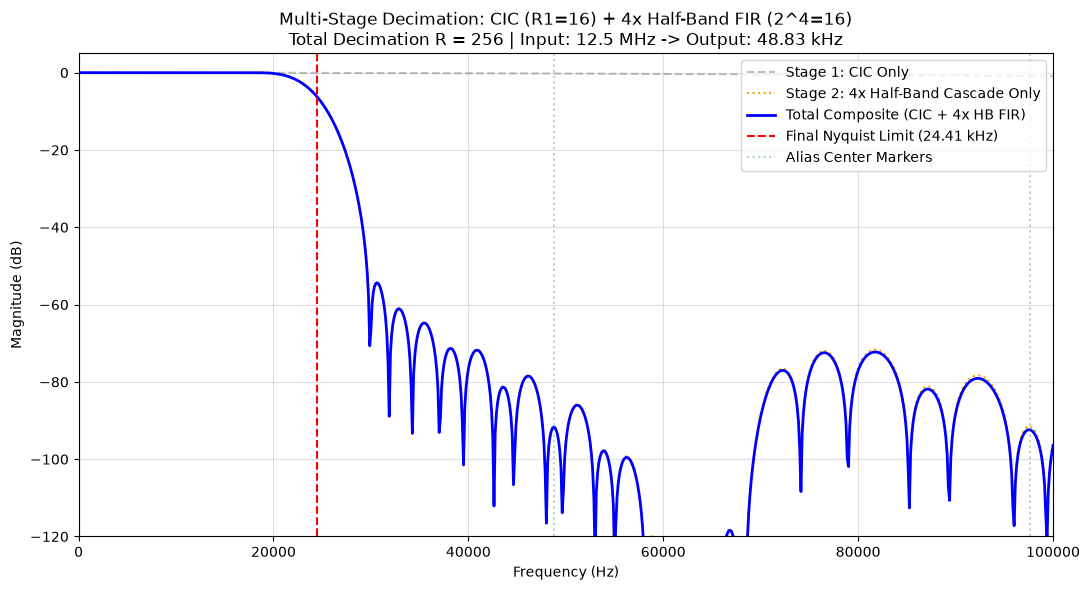

Generated Half-Band Filter Taps (31 Taps total):
[-0.0008  0.      0.0029  0.     -0.0072  0.      0.0147  0.     -0.0273
  0.      0.0494  0.     -0.097   0.      0.3152  0.5     0.3152  0.
 -0.097   0.      0.0494  0.     -0.0273  0.      0.0147  0.     -0.0072
  0.      0.0029  0.     -0.0008]

Zero-value Taps count: 14 out of 31 taps (Saving ~50% multipliers!)


In [19]:
plot_cic_with_4_halfband_cascade(R1=16, M=1, N_cic=4, hb_taps_count=31, fs_in=12500000.0, f_max_plot=1e6)